# AMI aberration basis inspector

Builds five candidate aberration bases **exactly as the pipeline would see them** (per-hole,
cropped to the `small_npix` window, evaluated on the *oversized* hexagon `f2f * oversize`), and lets you
inspect the first `N_MODES` vectors of each, on a single hole and assembled on the full AMI pupil.

| name | what it is |
|---|---|
| `zernike` | plain Zernikes on the hole's coordinates, cropped (`calc_basis(..., polike=False)`) |
| `polike` | polygon-mapped Zernikes (`dlu.polike_basis`, `calc_basis(..., polike=True)`) |
| `fourier` | raw separable Fourier dictionary, first N by spatial frequency, masked and unit-RMS normalised |
| `zernike_orth` | the `zernike` modes Gram-Schmidt / QR orthogonalised over `ORTH_ON` (Noll order kept, so mode *k* = Zernike *k* minus its projection onto modes < *k*), built as `Z R⁻¹ √n_valid` from the unmasked Zernikes so the modes stay defined over the whole oversized hexagon |
| `fourier_orth` | SVD-orthogonalised Fourier dictionary over `ORTH_ON`, built as `D V S⁻¹ √n_valid` from the unmasked dictionary so the modes stay defined over the whole oversized hexagon (with `ORTH_ON="oversized hexagon"` this spans the same modes as the pipeline's `orthogonalise_fourier_basis`) |

Everything is scaled to RMS ~ 1 inside the oversized hexagon (the Zernike convention the learning rates were tuned for).
**Note the pipeline evaluates the basis on the oversized hexagon (`oversize=1.2` -- the `AMIOptics` default, and what `retrain.py` uses via the dynamic mask; `StaticApertureMask` alone defaults to 1.1) but light only passes through the
holes themselves (nominally `f2f=0.80`)**, so orthogonality over the oversized hexagon does not imply orthogonality over the aperture.
Section 9 adds Milo's **eigenbasis** (`EIGEN_PATH`), which is different in kind: each mode spans the whole pupil (all seven
holes at once, one coefficient per mode), so it is kept separate from `bases` and analysed pupil-wide.

The diagnostics below let you choose which mask to measure on, and `ORTH_ON` chooses which region the two *orthogonalised* bases are made orthogonal over
(default: the nominal aperture; `"oversized hexagon"` reproduces what the pipeline builds today; `"fitted aperture"` orthogonalises each hole on its own fitted, distorted aperture from `STATE_PATH`).

In [1]:
import math, warnings
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as np
from jax import vmap
import numpy as onp
import dLux.utils as dlu
import matplotlib.pyplot as plt
from amigo import optical_models as om

warnings.filterwarnings("ignore")
plt.rcParams["image.origin"] = "lower"

# ---- knobs -----------------------------------------------------------------
N_MODES = 28            # first n modes of every basis
FOURIER_DICT_N = 13     # per-axis Fourier dictionary size (13 -> 169 modes), as in the pipeline
F2F, OVERSIZE = 0.80, 1.2   # AMIOptics default; retrain.py uses the dynamic mask (also 1.2). StaticApertureMask alone is 1.1
ORTH_ON = "nominal aperture"     # or "oversized hexagon" (= what the pipeline's fourier=True builds today) or "fitted aperture"
# ---- machine-dependent paths (same host logic as retrain.py) ---------------------------------------------
from socket import gethostname
if gethostname() in ("maxs-mbp-14.shared.sydney.edu.au", "Maxs-MacBook-Pro-14.local"):
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
elif gethostname().startswith("max-"):
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
else:
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
print(f"amigo_files_path: {amigo_files_path}")
STATE_PATH = amigo_files_path + "/final_statev46.npy"   # fitted distortion / primary_beam / transmission live here
EIGEN_PATH = amigo_files_path + "/eigenbasis_v1.npy"   # Milo's pupil-wide eigenbasis (section 9)
N_EIGEN = 100           # first n eigenmodes to load
DISTORTION_ORDERS = 3   # AMIOptics default; must match state["distortion"].shape == (2, 9)
DIAMETER, NPIX, SMALL = 6.603464, 1024, 180

ERROR:2026-09-25 06:16:06,617:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


## Geometry (as in `StaticApertureMask` / `DynamicApertureMask.__init__`)

In [2]:
coords = dlu.pixel_coords(NPIX, DIAMETER)
holes = om.get_initial_holes(DIAMETER, NPIX)
hole_coords = vmap(dlu.translate_coords, (None, 0))(coords, holes)
corners = om.calc_hole_corners(coords, holes, SMALL)
small = om.crop_hole_coords(hole_coords, corners, SMALL)     # (n_holes, 2, SMALL, SMALL)
pix = DIAMETER / NPIX
n_holes = small.shape[0]
f2f_ab = F2F * OVERSIZE                                       # what the aberration basis is built on

hexmask = lambda f: vmap(lambda c: dlu.soft_reg_polygon(c, f / np.sqrt(3), 6, pix))(small)
mask_nom = onp.asarray(hexmask(F2F))          # nominal aperture (f2f=0.80, undistorted)
mask_over = onp.asarray(hexmask(f2f_ab))       # oversized hexagon the bases live on
transmission = om.calc_mask(hole_coords, F2F, pix)            # full-pupil transmission
n_valid_over = (mask_over > 0.5).sum((-1, -2))
print(f"{n_holes} holes, window {SMALL}px, pixel {pix*1e3:.2f} mm, "
      f"valid px: nominal {(mask_nom>0.5).sum((-1,-2))[0]}, oversized {n_valid_over[0]}")

# ---- fitted (distorted) aperture from a saved state --------------------------------------
# The pipeline fits `distortion` (global) and `primary_beam` (per hole) of the DynamicApertureMask, so each
# hole's fitted aperture is a slightly different hexagon. Build the per-hole masks exactly as the pipeline does
# (DynamicApertureMask.sparse_apertures), once with zero coefficients (reference) and once with the fitted ones.
import os
state = onp.load(STATE_PATH, allow_pickle=True).item()

def dynamic_masks(distortion, primary_beam):
    layer = om.DynamicApertureMask(distortion_orders=DISTORTION_ORDERS, diameter=DIAMETER, npixels=NPIX,
                                   f2f=F2F, aberration_orders=1, oversize=OVERSIZE)
    layer = layer.set("transformation.distortion", np.asarray(distortion)).set("primary_beam", np.asarray(primary_beam))
    return onp.asarray(layer.sparse_apertures(NPIX, DIAMETER))

mask_nom_dyn = dynamic_masks(onp.zeros_like(state["distortion"]), onp.zeros_like(state["primary_beam"]))
# The state's `transmission` is the evaluated pupil.calc_mask() of the fitted model, i.e. the aperture the model actually used:
# crop each hole's window straight out of it. Rebuilding from distortion/primary_beam must agree (checked below).
mask_fit = onp.asarray(om.crop_windows(np.asarray(state["transmission"]), corners, SMALL))
mask_fit_from_coeffs = dynamic_masks(state["distortion"], state["primary_beam"])
FIT_LABEL = f"fitted aperture ({os.path.basename(STATE_PATH)})"
iou_fn = lambda a, b: ((a > .5) & (b > .5)).sum((-1, -2)) / ((a > .5) | (b > .5)).sum((-1, -2))
print("sanity: zero-coefficient dynamic mask vs the notebook's nominal mask, IoU per hole:", onp.round(iou_fn(mask_nom_dyn, mask_nom), 4))
print("saved transmission vs mask rebuilt from distortion/primary_beam, IoU per hole:", onp.round(iou_fn(mask_fit, mask_fit_from_coeffs), 4))
print("fitted vs zero-coefficient dynamic mask, IoU per hole:", onp.round(iou_fn(mask_fit, mask_nom_dyn), 4))


7 holes, window 180px, pixel 6.45 mm, valid px: nominal 13324, oversized 19202
sanity: zero-coefficient dynamic mask vs the notebook's nominal mask, IoU per hole: [0.9918 0.9801 0.9623 0.9801 0.959  0.983  0.9527]
saved transmission vs mask rebuilt from distortion/primary_beam, IoU per hole: [1. 1. 1. 1. 1. 1. 1.]
fitted vs zero-coefficient dynamic mask, IoU per hole: [0.9597 0.87   0.9752 0.8485 0.8596 0.9318 0.9178]


## Build the five bases  (`bases[name]` has shape `(n_holes, N_MODES, SMALL, SMALL)`)

In [3]:
# radial orders needed to cover N_MODES Noll modes
R_ORD = next(r for r in range(1, 30) if r * (r + 1) // 2 >= N_MODES)
unit_rms = lambda B, m: B / onp.sqrt(((B * m[:, None]) ** 2).sum((-1, -2), keepdims=True) / (m > 0.5).sum((-1, -2))[:, None, None, None])

bases = {}
bases["zernike"] = onp.asarray(om.calc_basis(small, f2f_ab, R_ORD, polike=False))[:, :N_MODES]
bases["polike"] = onp.asarray(om.calc_basis(small, f2f_ab, R_ORD, polike=True))[:, :N_MODES]

# raw Fourier: dictionary is independent of hole position, so build once. Order by spatial frequency.
fd = onp.asarray(om.calc_fourier_dict(small[0], f2f_ab, FOURIER_DICT_N))          # (169, S, S)
ii, jj = onp.divmod(onp.arange(FOURIER_DICT_N ** 2), FOURIER_DICT_N)
fx, fy = (ii + 1) // 2, (jj + 1) // 2
perm = onp.lexsort((jj, ii, fx ** 2 + fy ** 2))[:N_MODES]
fourier_labels = [f"kx={fx[p]}{'c' if ii[p]%2 else 's'} ky={fy[p]}{'c' if jj[p]%2 else 's'}" for p in perm]
bases["fourier"] = unit_rms(onp.broadcast_to(fd[perm], (n_holes, N_MODES, SMALL, SMALL)) * mask_over[:, None], mask_over)

def gram_schmidt(B, m):
    # QR over the aperture m: columns = modes. R is the exact old->new coefficient map (c_new = R c_old).
    # The modes are built from the *unmasked* B as B R^-1 sqrt(n_valid), so they are orthonormal over m but still
    # defined over the whole oversized hexagon (a fixed basis keeps covering the hole as the fitted aperture drifts).
    # Masking the modes to m instead (Q itself) would zero them wherever the aperture moves outside m.
    out, Rs = [], []
    for h in range(B.shape[0]):
        F = (B[h] * m[h]).reshape(B.shape[1], -1).T
        R = np.linalg.qr(F)[1]
        s = np.sign(np.diag(R)); s = np.where(s == 0, 1, s)
        R = onp.asarray(R * s[:, None])
        out.append(onp.tensordot(onp.linalg.inv(R).T, B[h], 1) * onp.sqrt((m[h] > 0.5).sum()) * mask_over[h])
        Rs.append(R)
    return onp.stack(out), onp.stack(Rs)

orth_mask = {"nominal aperture": mask_nom, "oversized hexagon": mask_over, "fitted aperture": mask_fit}[ORTH_ON]
bases["zernike_orth"], R_zorth = gram_schmidt(bases["zernike"], orth_mask)

def svd_orth(m, h):
    # SVD over the aperture m. As with gram_schmidt, build the modes from the *unmasked* dictionary
    # (U = F V S^-1, so mode = fd V S^-1 sqrt(n_valid)) so they stay defined over the whole oversized hexagon.
    F = (fd[None] * m[None, None]).reshape(fd.shape[0], -1).T
    U, s_, Vt = np.linalg.svd(F, full_matrices=False)
    W = onp.asarray(Vt[:N_MODES].T / s_[:N_MODES])                     # dictionary -> mode coefficients
    return onp.tensordot(W.T, fd, 1) * onp.sqrt((m > 0.5).sum()) * mask_over[h]

bases["fourier_orth"] = onp.stack([svd_orth(orth_mask[h], h) for h in range(n_holes)])
if ORTH_ON == "oversized hexagon":
    ref = onp.asarray(om.orthogonalise_fourier_basis(small[0], f2f_ab, FOURIER_DICT_N, N_MODES))
    # individual SVD modes are only defined up to sign / rotation within (near-)degenerate singular-value
    # groups (the hexagon is 6-fold symmetric), so compare the *spanned subspace*, not mode-by-mode.
    v = orth_mask[0] > 0.5
    A, Bm = bases["fourier_orth"][0][:, v].T, ref[:, v].T
    resid = Bm - A @ onp.linalg.lstsq(A, Bm, rcond=None)[0]
    print("pipeline orthogonalise_fourier_basis vs this cell (hole 0): subspace residual", onp.abs(resid).max(), "(basis values ~1)")
NAMES = list(bases)
print({k: v.shape for k, v in bases.items()})

{'zernike': (7, 28, 180, 180), 'polike': (7, 28, 180, 180), 'fourier': (7, 28, 180, 180), 'zernike_orth': (7, 28, 180, 180), 'fourier_orth': (7, 28, 180, 180)}


## Helpers
`MASKS` picks the region diagnostics/plots are measured on: the nominal 0.80 aperture, the oversized hexagon the bases are built on, or the fitted aperture.

In [4]:
MASKS = {"nominal aperture (f2f=0.80)": mask_nom, f"oversized hexagon (x{OVERSIZE})": mask_over, FIT_LABEL: mask_fit}

def masked(B, m):
    return onp.where(m > 0.5, B, onp.nan)

def corr_matrix(A, B, m):
    # normalised inner product over the mask: (N,N) matrix of <a_i, b_j> / (|a_i||b_j|)
    v = m > 0.5
    a, b = A[:, v], B[:, v]
    G = a @ b.T
    return G / onp.outer(onp.sqrt((a * a).sum(1)), onp.sqrt((b * b).sum(1)))

def summarise(name, hole, m):
    C = corr_matrix(bases[name][hole], bases[name][hole], m[hole])
    off = onp.abs(C - onp.eye(len(C)))
    w = onp.linalg.eigvalsh(C)
    return off.max(), w.max() / max(w.min(), 1e-15)

## 1. Orthogonality / conditioning diagnostics

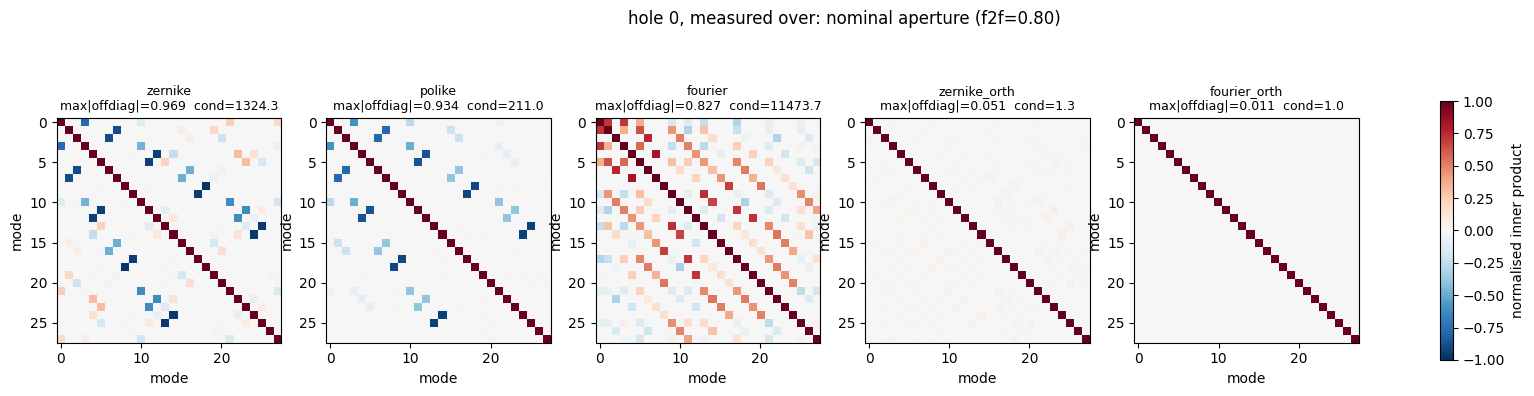

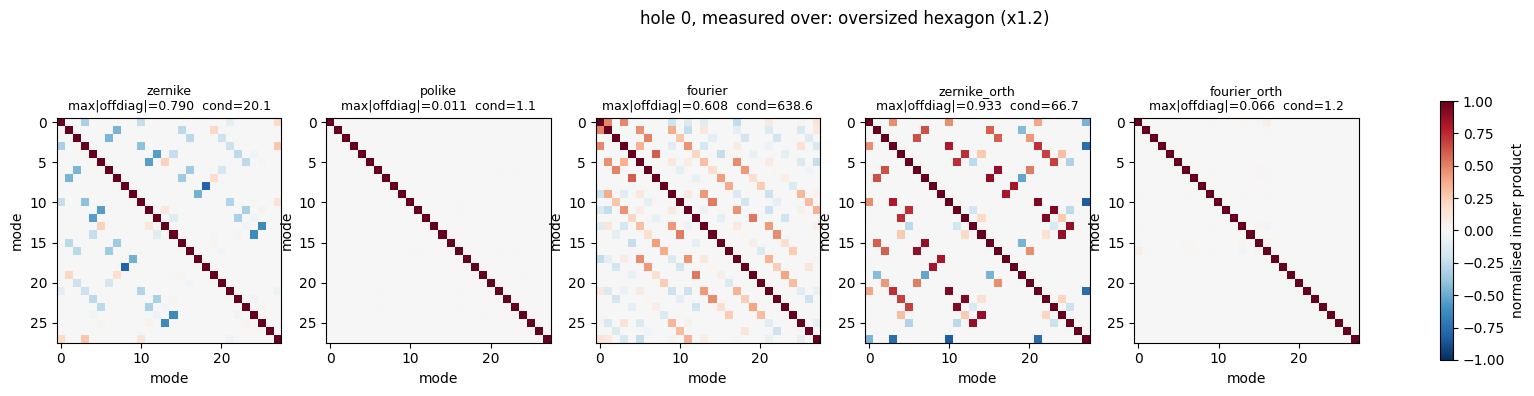

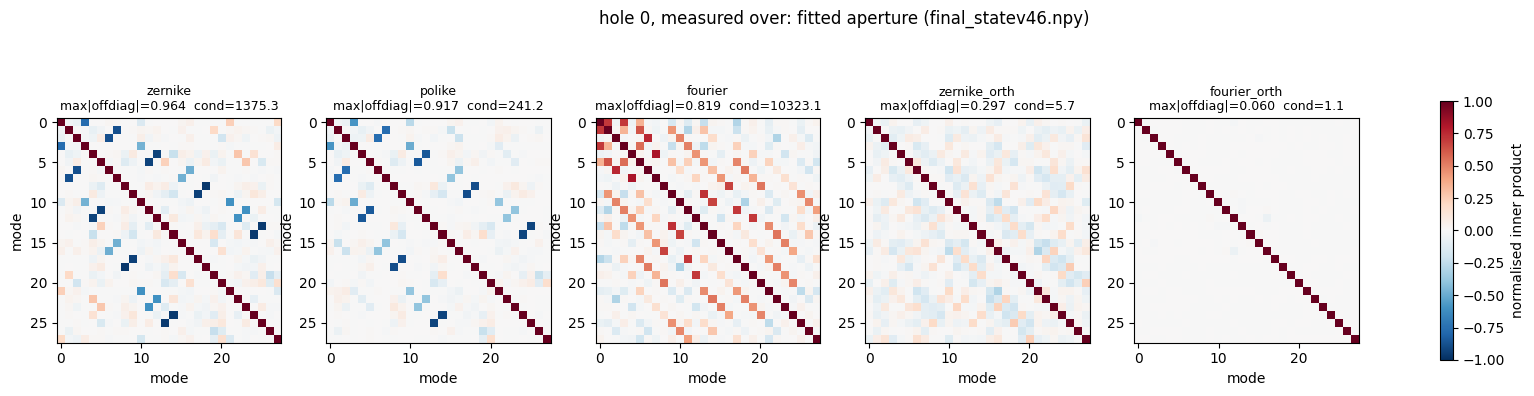

In [5]:
def diagnostics(hole=0, mask_name=list(MASKS)[0]):
    m = MASKS[mask_name]
    fig, ax = plt.subplots(1, len(NAMES), figsize=(4.2 * len(NAMES), 4.2))
    for a, name in zip(ax, NAMES):
        C = corr_matrix(bases[name][hole], bases[name][hole], m[hole])
        off, cond = summarise(name, hole, m)
        im = a.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r", origin="upper")
        a.set_title(f"{name}\nmax|offdiag|={off:.3f}  cond={cond:.1f}", fontsize=9); a.set(xlabel="mode", ylabel="mode")
    fig.colorbar(im, ax=ax, shrink=0.8, label="normalised inner product")
    fig.suptitle(f"hole {hole}, measured over: {mask_name}", y=1.02)
    plt.show()

for mn in MASKS:
    diagnostics(0, mn)

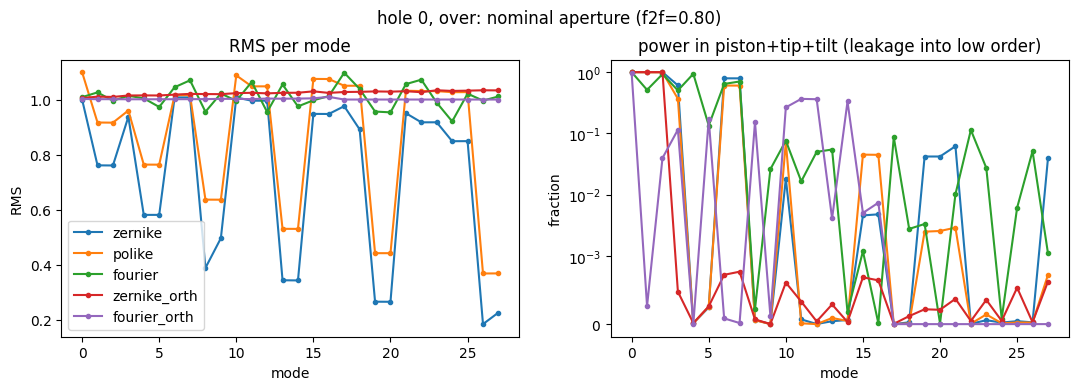

In [6]:
# per-mode RMS over the chosen mask, and linear-fit (piston+tip+tilt) power of each mode
def per_mode_stats(hole=0, mask_name=list(MASKS)[0]):
    m = MASKS[mask_name][hole] > 0.5
    x, y = [onp.asarray(c)[m] for c in small[hole]]
    P = onp.stack([onp.ones_like(x), x, y], 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
    for name in NAMES:
        B = bases[name][hole][:, m]
        ax[0].plot(onp.sqrt((B ** 2).mean(1)), "o-", ms=3, label=name)
        coef = onp.linalg.lstsq(P, B.T, rcond=None)[0]
        r2 = ((P @ coef) ** 2).sum(0) / (B ** 2).sum(1)
        ax[1].plot(r2, "o-", ms=3, label=name)
    ax[0].set(title="RMS per mode", xlabel="mode", ylabel="RMS"); ax[0].legend()
    ax[1].set(title="power in piston+tip+tilt (leakage into low order)", xlabel="mode", ylabel="fraction"); ax[1].set_yscale("symlog", linthresh=1e-3)
    fig.suptitle(f"hole {hole}, over: {mask_name}", y=1.02); plt.show()

per_mode_stats(0, list(MASKS)[0])

## 2. Are `polike` and `zernike_orth` the same thing?
Cross-correlation of the two bases (rows: `polike`, cols: `zernike_orth`). A near-diagonal matrix means `polike` ~ Gram-Schmidt Zernike; off-diagonal
structure shows where they differ. Any pair of bases can be compared.

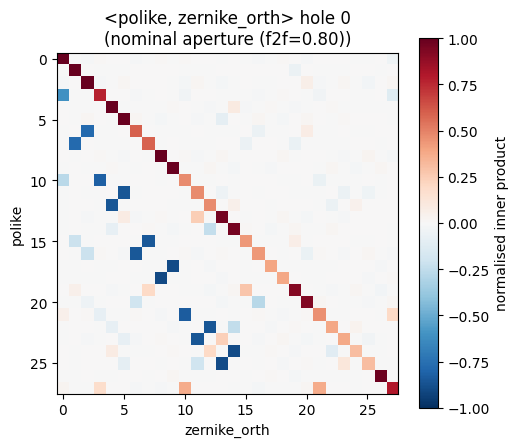

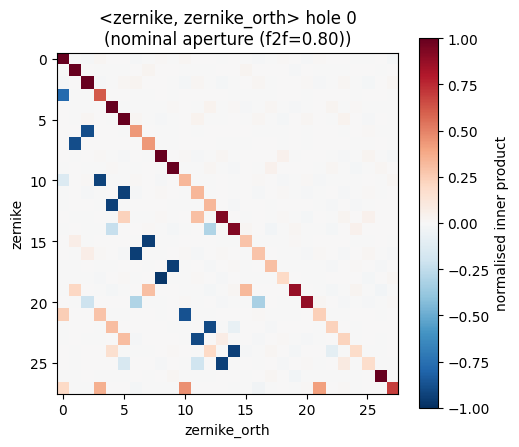

In [7]:
def cross(a="polike", b="zernike_orth", hole=0, mask_name=list(MASKS)[0]):
    C = corr_matrix(bases[a][hole], bases[b][hole], MASKS[mask_name][hole])
    plt.figure(figsize=(5.5, 4.8)); plt.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r", origin="upper"); plt.colorbar(label="normalised inner product")
    plt.gca().set(title=f"<{a}, {b}> hole {hole}\n({mask_name})", xlabel=b, ylabel=a); plt.show()

cross("polike", "zernike_orth")
cross("zernike", "zernike_orth")

## 3. polike vs the hexagonal mask
`polike` assumes a particular polygon orientation (vertices at 30/90/150 deg). If the aperture is rotated relative to that, polike
is no longer orthogonal and shows edge artefacts. IoU of polike's implied hexagon vs the actual mask, at 0 and 30 deg rotation:

rot  0 deg: IoU polike-hexagon vs oversized mask, holes: min 1.0000 mean 1.0000
rot 30 deg: IoU polike-hexagon vs oversized mask, holes: min 0.8659 mean 0.8659


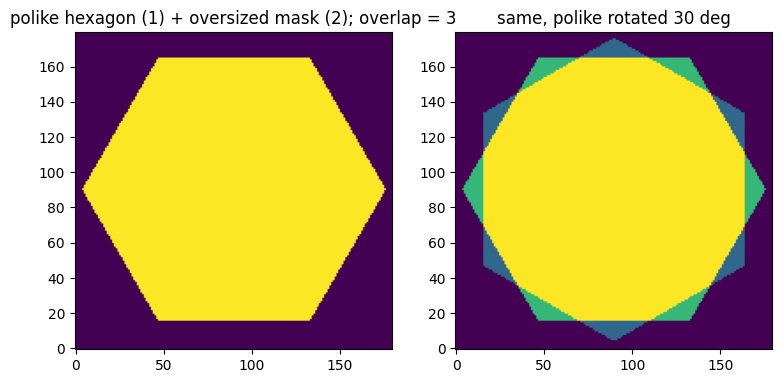

In [8]:
def polike_hex(c, rot=0.0):
    x, y = c[0], c[1]
    th = np.arctan2(y, x) + rot
    al = np.pi / 6
    u = th + al - np.floor((th + 2 * al) / (2 * al)) * 2 * al
    r_al = np.cos(al) / np.cos(u)
    return (np.hypot(x, y) / (f2f_ab / np.sqrt(3))) <= r_al

for rot_deg in (0, 30):
    ph = onp.asarray(vmap(lambda c: polike_hex(c, onp.deg2rad(rot_deg)))(small))
    hexm = mask_over > 0.5
    iou = (ph & hexm).sum((-1, -2)) / (ph | hexm).sum((-1, -2))
    print(f"rot {rot_deg:2d} deg: IoU polike-hexagon vs oversized mask, holes: min {iou.min():.4f} mean {iou.mean():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ph0 = onp.asarray(polike_hex(small[0])); ax[0].imshow(ph0 * 1.0 + 2.0 * (mask_over[0] > 0.5), cmap="viridis")
ax[0].set(title="polike hexagon (1) + oversized mask (2); overlap = 3")
ph30 = onp.asarray(polike_hex(small[0], onp.deg2rad(30))); ax[1].imshow(ph30 * 1.0 + 2.0 * (mask_over[0] > 0.5), cmap="viridis")
ax[1].set(title="same, polike rotated 30 deg"); plt.show()

## 4. Single-hole mode viewer

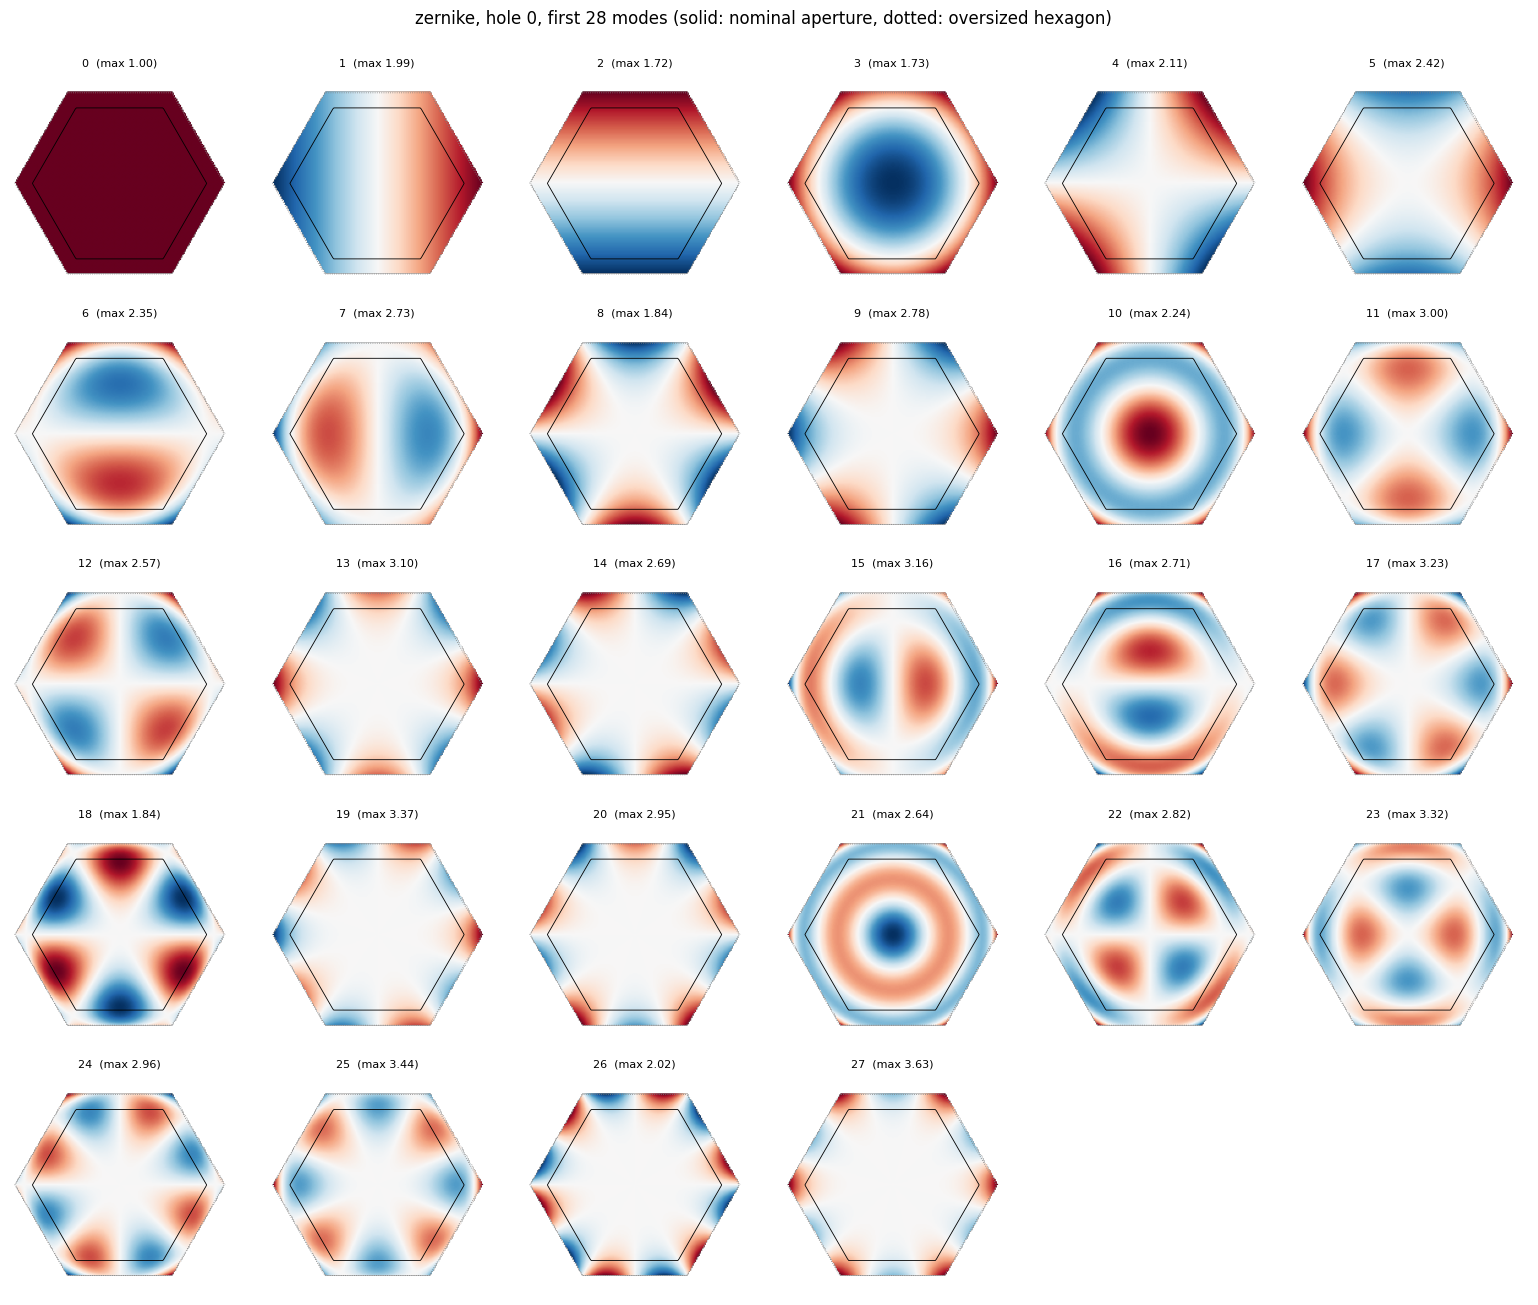

In [9]:
def show_modes(name="zernike", hole=0, n=12, mask_name=list(MASKS)[1], ncols=6, outline=True):
    B = masked(bases[name][hole][:n], MASKS[mask_name][hole])
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.6 * nrows), squeeze=False)
    for k, a in enumerate(axes.ravel()):
        a.axis("off")
        if k >= n: continue
        v = onp.nanmax(onp.abs(B[k]))
        a.imshow(B[k], cmap="RdBu_r", vmin=-v, vmax=v)
        if outline:
            a.contour(mask_nom[hole], [0.5], colors="k", linewidths=0.6)
            a.contour(mask_over[hole], [0.5], colors="0.5", linewidths=0.6, linestyles=":")
        lab = f"{k}" + (f"  {fourier_labels[k]}" if name == "fourier" else "")
        a.set_title(f"{lab}  (max {v:.2f})", fontsize=8)
    fig.suptitle(f"{name}, hole {hole}, first {n} modes (solid: nominal aperture, dotted: oversized hexagon)", y=1.0)
    plt.tight_layout(); plt.show()

show_modes("zernike", n=N_MODES)

## 5. Assembled on the AMI pupil

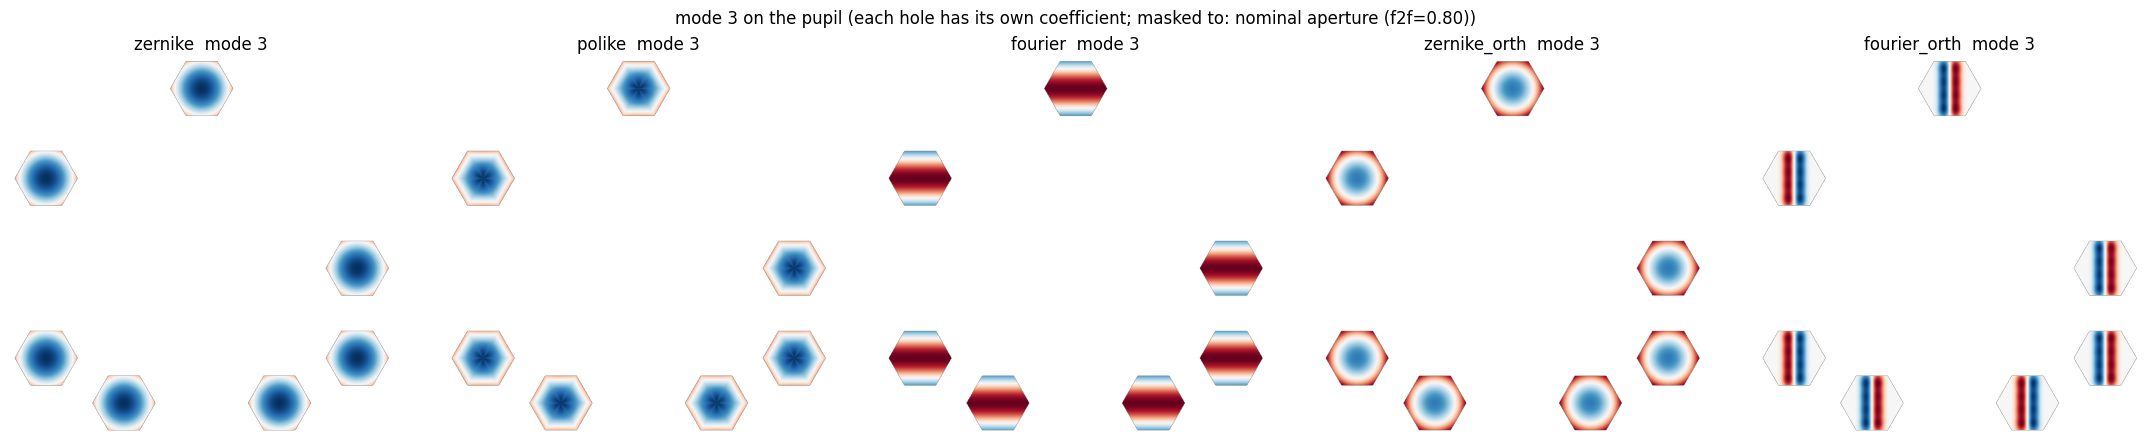

In [10]:
def pupil_map(name, k, mask_name=list(MASKS)[0]):
    B = bases[name][:, k] * (MASKS[mask_name] > 0.5)            # (n_holes, S, S), zero outside the chosen aperture
    return onp.asarray(om.fill(np.asarray(B), corners, NPIX))

def show_pupils(k=3, names=NAMES, mask_name=list(MASKS)[0], crop=True):
    maps = {n: pupil_map(n, k, mask_name) for n in names}
    sup = onp.abs(onp.asarray(transmission)) > 0
    ys, xs = onp.where(sup)
    sl = (slice(ys.min() - 10, ys.max() + 10), slice(xs.min() - 10, xs.max() + 10)) if crop else (slice(None), slice(None))
    fig, ax = plt.subplots(1, len(names), figsize=(4.4 * len(names), 4.4))
    for a, n in zip(onp.atleast_1d(ax), names):
        im = maps[n][sl]; v = onp.abs(im).max() or 1
        a.imshow(onp.where(im == 0, onp.nan, im), cmap="RdBu_r", vmin=-v, vmax=v)
        a.set(title=f"{n}  mode {k}"); a.axis("off")
    fig.suptitle(f"mode {k} on the pupil (each hole has its own coefficient; masked to: {mask_name})", y=1.0)
    plt.tight_layout(); plt.show()

show_pupils(3)

## 6. Fitted (distorted) aperture
The bases are built on the *nominal* hexagon (unless `ORTH_ON="fitted aperture"`), but the pipeline fits `distortion` and `primary_beam`, so each hole's actual aperture is a
slightly different hexagon (shifted, scaled, sheared). Orthogonality on the nominal aperture therefore does not survive on the fitted one. This section takes each hole's aperture from the saved state's `transmission` (the evaluated `calc_mask()` of the fitted model; rebuilding it from `distortion`/`primary_beam` with `DynamicApertureMask.sparse_apertures` is used as a cross-check), quantifies how far it moved, and re-measures every basis on it. The fitted aperture is also added to the
`MASKS` choices, so all diagnostics/viewers above and the interactive cells below can be pointed at it.

hole  area chg %  centroid shift (px)    (mm)     IoU
   0       1.103                1.870   12.06  0.9597
   1       0.713                7.083   45.68  0.8700
   2       1.126                1.229    7.93  0.9752
   3       0.923                8.290   53.46  0.8485
   4       1.396                7.163   46.19  0.8596
   5       1.516                3.220   20.77  0.9318
   6       0.615                4.132   26.65  0.9178


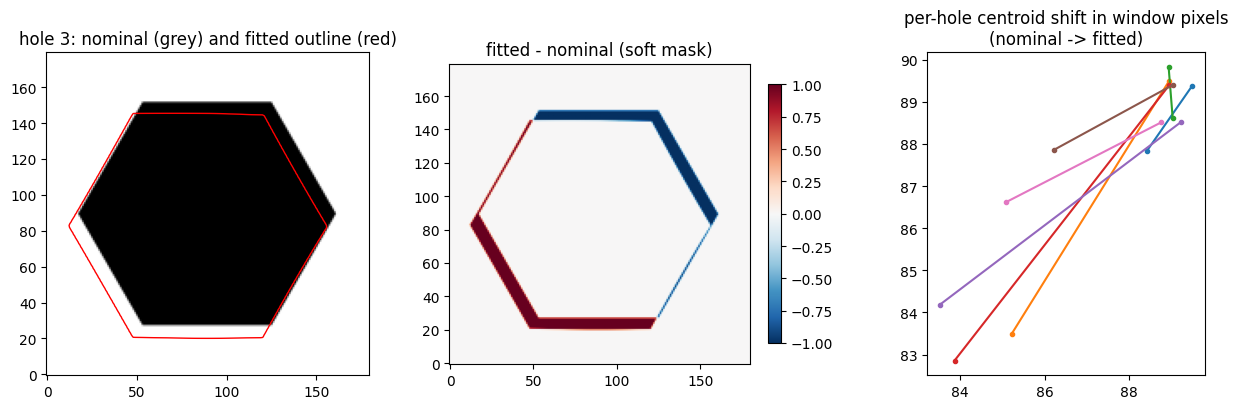

In [11]:
def moments(m):
    v = m > 0.5
    yy, xx = onp.indices(m.shape[-2:])
    area = v.sum((-1, -2))
    return area, (v * xx).sum((-1, -2)) / area, (v * yy).sum((-1, -2)) / area

a0, cx0, cy0 = moments(mask_nom_dyn)
a1, cx1, cy1 = moments(mask_fit)
print(f"{'hole':>4} {'area chg %':>11} {'centroid shift (px)':>20} {'(mm)':>7} {'IoU':>7}")
for h in range(n_holes):
    d = onp.hypot(cx1[h] - cx0[h], cy1[h] - cy0[h])
    print(f"{h:4d} {100 * (a1[h] / a0[h] - 1):11.3f} {d:20.3f} {d * pix * 1e3:7.2f} {iou_fn(mask_fit, mask_nom_dyn)[h]:7.4f}")

worst_geo = int(onp.argmin(iou_fn(mask_fit, mask_nom_dyn)))
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
ax[0].imshow(mask_nom_dyn[worst_geo], cmap="gray_r"); ax[0].contour(mask_fit[worst_geo], [0.5], colors="r", linewidths=1)
ax[0].set(title=f"hole {worst_geo}: nominal (grey) and fitted outline (red)")
d = mask_fit[worst_geo] - mask_nom_dyn[worst_geo]
v = onp.abs(d).max()
im = ax[1].imshow(d, cmap="RdBu_r", vmin=-v, vmax=v); ax[1].set(title="fitted - nominal (soft mask)"); fig.colorbar(im, ax=ax[1], shrink=0.8)
for h in range(n_holes):
    ax[2].plot([cx0[h], cx1[h]], [cy0[h], cy1[h]], "-o", ms=3)
ax[2].set(title="per-hole centroid shift in window pixels\n(nominal -> fitted)", aspect="equal"); plt.tight_layout(); plt.show()

orthogonalised bases were built on: ORTH_ON = 'nominal aperture'
Worst hole per basis; nominal = zero-coefficient dynamic mask, fitted = STATE_PATH coefficients.
basis          | nominal max|off|     cond | fitted max|off|     cond | worst fitted hole
zernike        |            0.969   1533.9 |           0.967   5061.7 | 3
polike         |            0.933    278.8 |           0.927   1231.9 | 3
fourier        |            0.827  11486.3 |           0.823  10616.0 | 6
zernike_orth   |            0.271      5.6 |           0.775    297.9 | 3
fourier_orth   |            0.055      1.1 |           0.215      1.7 | 3


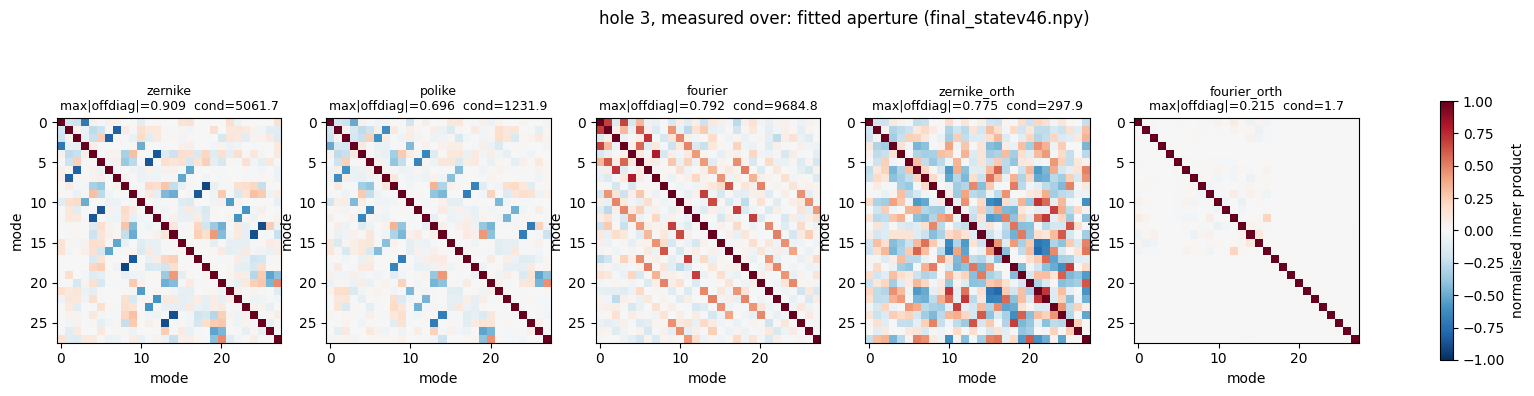

In [12]:

def offdiag_cond(name, h, m):
    C = corr_matrix(bases[name][h], bases[name][h], m[h])
    w = onp.linalg.eigvalsh(C)
    return onp.abs(C - onp.eye(len(C))).max(), w.max() / max(w.min(), 1e-15)

print(f"orthogonalised bases were built on: ORTH_ON = {ORTH_ON!r}")
print("Worst hole per basis; nominal = zero-coefficient dynamic mask, fitted = STATE_PATH coefficients.")
print(f"{'basis':14s} | {'nominal max|off|':>16s} {'cond':>8s} | {'fitted max|off|':>15s} {'cond':>8s} | worst fitted hole")
for name in NAMES:
    nom = [offdiag_cond(name, h, mask_nom_dyn) for h in range(n_holes)]
    fit = [offdiag_cond(name, h, mask_fit) for h in range(n_holes)]
    hw = int(onp.argmax([f[1] for f in fit]))
    print(f"{name:14s} | {max(n[0] for n in nom):16.3f} {max(n[1] for n in nom):8.1f} | {max(f[0] for f in fit):15.3f} {max(f[1] for f in fit):8.1f} | {hw}")

diagnostics(worst_geo, FIT_LABEL)          # full correlation matrices on the most-changed hole


## 7. Interactive
Sliders for basis / mode / hole / mask. (Requires a live Jupyter kernel; the static cells above cover the same views.)

In [13]:
import ipywidgets as w
from IPython.display import display

basis_dd = w.Dropdown(options=NAMES, value="zernike", description="basis")
mask_dd = w.Dropdown(options=list(MASKS), value=list(MASKS)[0], description="mask")
hole_s = w.IntSlider(0, 0, n_holes - 1, description="hole")
mode_s = w.IntSlider(3, 0, N_MODES - 1, description="mode k")
n_s = w.IntSlider(12, 1, N_MODES, description="first n")

w.interact(lambda name, hole, n, mask_name: show_modes(name, hole, n, mask_name), name=basis_dd, hole=hole_s, n=n_s, mask_name=mask_dd)
w.interact(lambda k, mask_name: show_pupils(k, NAMES, mask_name), k=mode_s, mask_name=mask_dd)
w.interact(lambda hole, mask_name: diagnostics(hole, mask_name), hole=hole_s, mask_name=mask_dd)

interactive(children=(Dropdown(description='basis', options=('zernike', 'polike', 'fourier', 'zernike_orth', '…

interactive(children=(IntSlider(value=3, description='mode k', max=27), Dropdown(description='mask', options=(…

interactive(children=(IntSlider(value=0, description='hole', max=6), Dropdown(description='mask', options=('no…

<function __main__.<lambda>(hole, mask_name)>

## 8. Converting existing Zernike coefficients into the orthogonalised basis
`R_zorth[h]` is the upper-triangular matrix from the QR of the Zernikes masked to `ORTH_ON`, and `zernike_orth = Z R⁻¹ √n_valid` (modes as columns), so a wavefront `Z c_old` equals `zernike_orth (R c_old / √n_valid)`.
The exact new coefficients for a fitted state are `c_new = R c_old`, which is what lets a converged Zernike checkpoint be loaded into `zernike_orth`
(exact for the first N modes because R is upper-triangular, so truncation commutes with the change of basis). Because `zernike_orth` is built from the unmasked Zernikes, the conversion is exact over the whole oversized hexagon, not just over `ORTH_ON`; wavefronts are compared there.

In [14]:
c_old = onp.random.default_rng(0).normal(size=N_MODES)          # a random Zernike wavefront
h = 0
nv = (orth_mask[h] > 0.5).sum()
wf_old = onp.tensordot(c_old, bases["zernike"][h], 1) * mask_over[h]
c_new = R_zorth[h] @ c_old / onp.sqrt(nv)                        # basis_orth = Z R^-1 sqrt(nv)  ->  c_new = R c_old / sqrt(nv)
wf_new = onp.tensordot(c_new, bases["zernike_orth"][h], 1)
print("max |wavefront difference| after conversion:", onp.abs(wf_old - wf_new).max(), " (wavefront max:", onp.abs(wf_old).max(), ")")

max |wavefront difference| after conversion: 1.865174681370263e-14  (wavefront max: 18.06422111852329 )


## 9. Eigenbasis (Milo, `eigenbasis_v1.npy`)
`N_EIGEN` pupil-wide modes, delivered as `(N, 1024, 1024)` maps that are `NaN` outside their support. The support is exactly
the seven oversized hexagons (`f2f × OVERSIZE`) at the nominal hole positions, the modes are orthonormal over it, and global
piston, tip, tilt and defocus have been projected out. Per-hole pistons (and tip/tilts) are meant to stay in.

Because the oversized hexagons don't overlap, each mode is stored here as per-hole windows, `eigen` with shape
`(N_EIGEN, n_holes, SMALL, SMALL)`, with nothing lost or double-counted (checked below), and rescaled to RMS 1 over the
support like the other bases. Unlike the per-hole bases, **every inner product in this section is summed over the whole
pupil**, all holes together.

In [15]:
E_full = onp.load(EIGEN_PATH, mmap_mode="r")[:N_EIGEN]  # (N_EIGEN, NPIX, NPIX), NaN outside the support
supp = onp.asarray(mask_over) > 0  # each hole's oversized hexagon, soft edge included
crop = lambda a: onp.asarray(om.crop_windows(np.asarray(a), corners, SMALL))
eigen = onp.stack([crop(onp.nan_to_num(E_full[k])) for k in range(len(E_full))]) * supp  # (N_EIGEN, n_holes, S, S)
n_eig, n_supp = eigen.shape[0], supp.sum()

supp_full = onp.asarray(om.fill(np.asarray(supp, float), corners, NPIX)) > 0
print(f"{n_eig} modes; support matches the oversized hexagons pixel for pixel: {bool((onp.isfinite(E_full[0]) == supp_full).all())}")
ss = (eigen**2).sum((1, 2, 3))
print(f"sum of squares kept by the windows (1 = nothing lost or double-counted): min {ss.min():.12f}, max {ss.max():.12f}")
eigen = eigen * onp.sqrt(n_supp)  # RMS 1 over the support, like the other bases

100 modes; support matches the oversized hexagons pixel for pixel: True
sum of squares kept by the windows (1 = nothing lost or double-counted): min 1.000000000000, max 1.000000000000


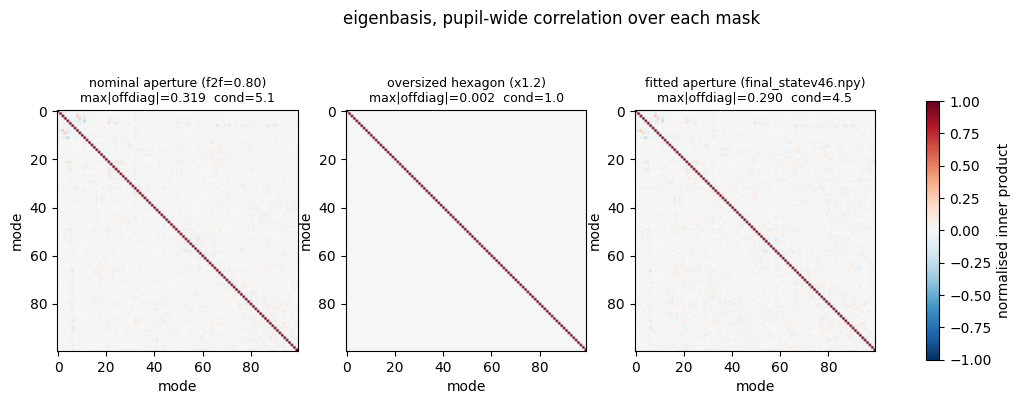

In [16]:
def pupil_corr(V, m):
    # normalised pupil-wide inner products of the modes in V (n, n_holes, S, S) over mask m
    v = V[:, m > 0.5]
    G = v @ v.T
    d = onp.sqrt(onp.diag(G))
    return G / onp.outer(d, d)


def eigen_diagnostics(masks=list(MASKS)):
    fig, ax = plt.subplots(1, len(masks), figsize=(4.4 * len(masks), 4.2))
    for a, mn in zip(onp.atleast_1d(ax), masks):
        C = pupil_corr(eigen, MASKS[mn])
        w_ = onp.linalg.eigvalsh(C)
        im = a.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r", origin="upper")
        a.set_title(f"{mn}\nmax|offdiag|={onp.abs(C - onp.eye(n_eig)).max():.3f}  cond={w_.max() / w_.min():.1f}", fontsize=9)
        a.set(xlabel="mode", ylabel="mode")
    fig.colorbar(im, ax=ax, shrink=0.8, label="normalised inner product")
    fig.suptitle("eigenbasis, pupil-wide correlation over each mask", y=1.02)
    plt.show()


eigen_diagnostics()

### Low-order content
Left: the fraction of each eigenmode lying in **global** piston / tip / tilt / defocus (these were projected out over the
support, so ~0 on the oversized hexagon, but they can leak back in on a smaller aperture). Right: the fraction of each
hole's **own** piston, tip and tilt (after removing their global part, which the basis excludes by design) that the
eigenbasis can represent. 1 means fully kept.

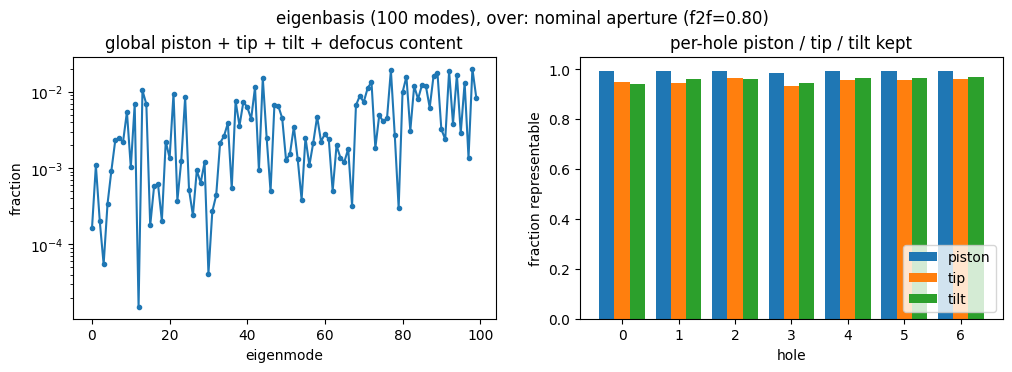

per-hole kept fraction (rows piston/tip/tilt, cols holes):
 [[0.9941 0.9932 0.993  0.9866 0.9949 0.9935 0.9932]
 [0.9499 0.9462 0.9673 0.935  0.958  0.9593 0.9601]
 [0.9429 0.962  0.9595 0.9465 0.9645 0.9647 0.9693]]


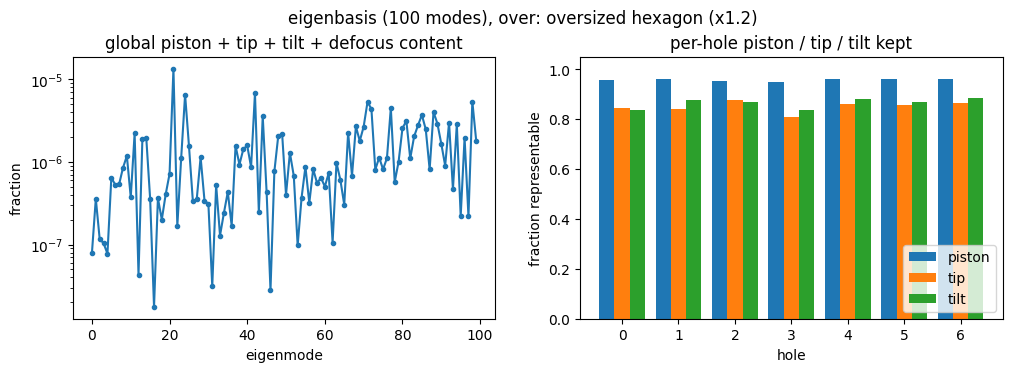

per-hole kept fraction (rows piston/tip/tilt, cols holes):
 [[0.9588 0.9603 0.9531 0.9505 0.9629 0.9617 0.962 ]
 [0.8445 0.8395 0.8773 0.8107 0.8612 0.8587 0.8633]
 [0.8371 0.8784 0.8677 0.8355 0.8816 0.8684 0.8864]]


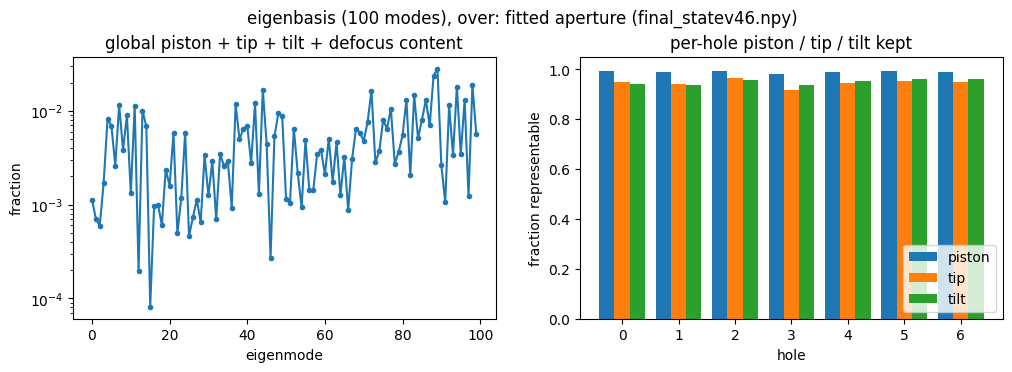

per-hole kept fraction (rows piston/tip/tilt, cols holes):
 [[0.9927 0.9893 0.9922 0.9816 0.9915 0.9922 0.9907]
 [0.9483 0.9398 0.9648 0.9169 0.9446 0.9536 0.9474]
 [0.9412 0.9391 0.9576 0.9365 0.9534 0.9611 0.9608]]


In [17]:
gx, gy = crop(coords[0]), crop(coords[1])  # global pupil coordinates in each window
lx, ly = onp.asarray(small[:, 0]), onp.asarray(small[:, 1])  # hole-centred coordinates
glob = onp.stack([onp.ones_like(gx), gx, gy, gx**2 + gy**2]) * supp  # global piston, tip, tilt, defocus
hole_ind = onp.eye(n_holes)[:, :, None, None] * supp[None]  # (n_holes, n_holes, S, S)
per_hole = onp.concatenate([hole_ind, hole_ind * lx[None], hole_ind * ly[None]])  # per-hole piston, tip, tilt


def span_q(V, m):
    # orthonormal basis (columns) of span(V) over mask m, pupil-wide
    return onp.linalg.qr(V[:, m > 0.5].T)[0]


def loworder_report(mask_name=f"oversized hexagon (x{OVERSIZE})"):
    m = MASKS[mask_name]
    Qe, Qg = span_q(eigen, m), span_q(glob, m)
    v = eigen[:, m > 0.5]
    leak = ((v @ Qg) ** 2).sum(1) / (v**2).sum(1)
    ph = per_hole[:, m > 0.5]
    ph = ph - (ph @ Qg) @ Qg.T  # drop the global part
    kept = (((ph @ Qe) ** 2).sum(1) / (ph**2).sum(1)).reshape(3, n_holes)

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
    ax[0].semilogy(onp.maximum(leak, 1e-18), "o-", ms=3)
    ax[0].set(xlabel="eigenmode", ylabel="fraction", title="global piston + tip + tilt + defocus content")
    x = onp.arange(n_holes)
    for i, lab in enumerate(["piston", "tip", "tilt"]):
        ax[1].bar(x + (i - 1) * 0.27, kept[i], 0.27, label=lab)
    ax[1].set(xlabel="hole", ylabel="fraction representable", ylim=(0, 1.05), title="per-hole piston / tip / tilt kept")
    ax[1].legend(loc="lower right")
    fig.suptitle(f"eigenbasis ({n_eig} modes), over: {mask_name}", y=1.02)
    plt.show()
    print("per-hole kept fraction (rows piston/tip/tilt, cols holes):\n", onp.round(kept, 4))


for mn in MASKS:
    loworder_report(mn)

### Eigenbasis vs the per-hole bases
Left: the fraction of each eigenmode that a per-hole basis **cannot** represent (each hole gets its own `N_MODES`
coefficients, so a per-hole basis spans `n_holes × N_MODES` pupil-wide directions). Right: the fraction of each per-hole
mode (averaged over holes) that the eigenbasis **can** represent. Both are least-squares projections over the chosen mask.

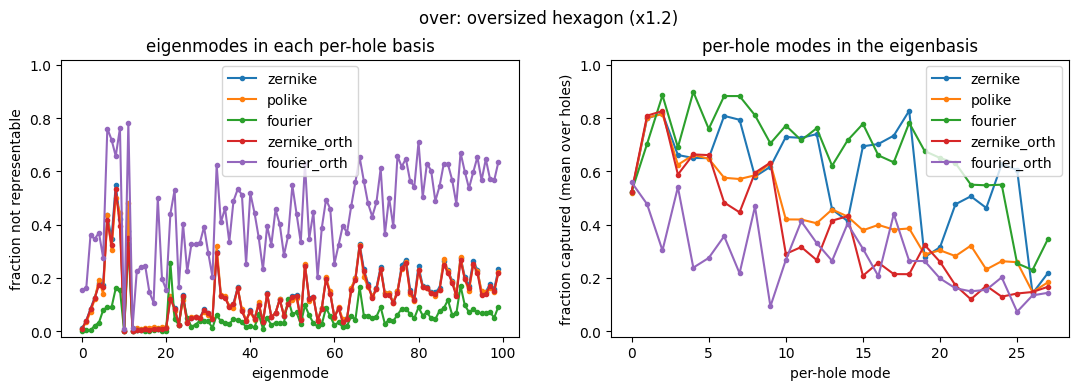

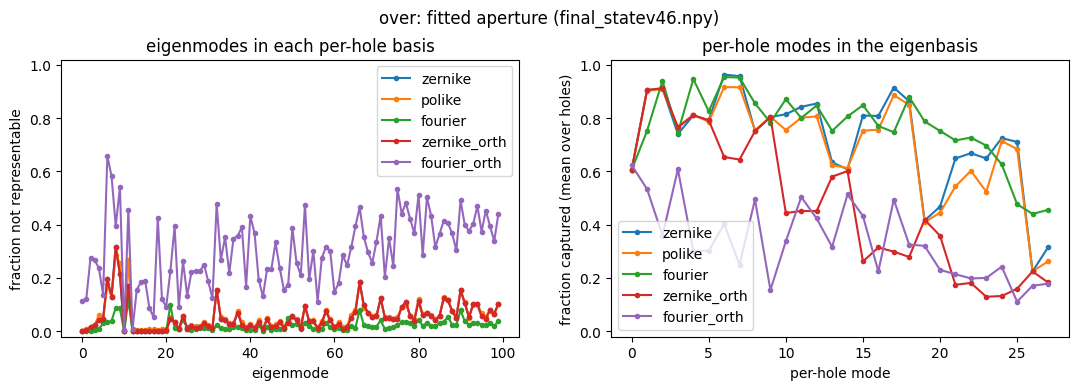

In [18]:
def eigen_vs_perhole(mask_name=f"oversized hexagon (x{OVERSIZE})", names=NAMES):
    m = MASKS[mask_name] > 0.5
    Qe = onp.linalg.qr(eigen[:, m].T)[0]  # eigenbasis span, pupil-wide
    hole_of = onp.broadcast_to(onp.arange(n_holes)[:, None, None], m.shape)[m]  # hole of each row of Qe
    e_norm = (eigen[:, m] ** 2).sum(1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
    for name in names:
        B = bases[name]
        unexpl, cap = onp.zeros(n_eig), onp.zeros((n_holes, B.shape[1]))
        for h in range(n_holes):
            b = B[h][:, m[h]]
            Qh = onp.linalg.qr(b.T)[0]  # this hole's span
            e = eigen[:, h][:, m[h]]
            unexpl += ((e - (e @ Qh) @ Qh.T) ** 2).sum(1)
            Qeh = Qe[hole_of == h]
            cap[h] = ((b @ Qeh) ** 2).sum(1) / (b**2).sum(1)
        ax[0].plot(unexpl / e_norm, "o-", ms=3, label=name)
        ax[1].plot(cap.mean(0), "o-", ms=3, label=name)
    ax[0].set(xlabel="eigenmode", ylabel="fraction not representable", ylim=(-0.02, 1.02), title="eigenmodes in each per-hole basis")
    ax[1].set(xlabel="per-hole mode", ylabel="fraction captured (mean over holes)", ylim=(-0.02, 1.02), title="per-hole modes in the eigenbasis")
    ax[0].legend(); ax[1].legend()
    fig.suptitle(f"over: {mask_name}", y=1.02)
    plt.show()


eigen_vs_perhole()
eigen_vs_perhole(FIT_LABEL)

### Eigenmode viewer
Modes assembled on the pupil, restricted to the chosen mask. Solid outlines: the nominal `f2f=0.80` holes.

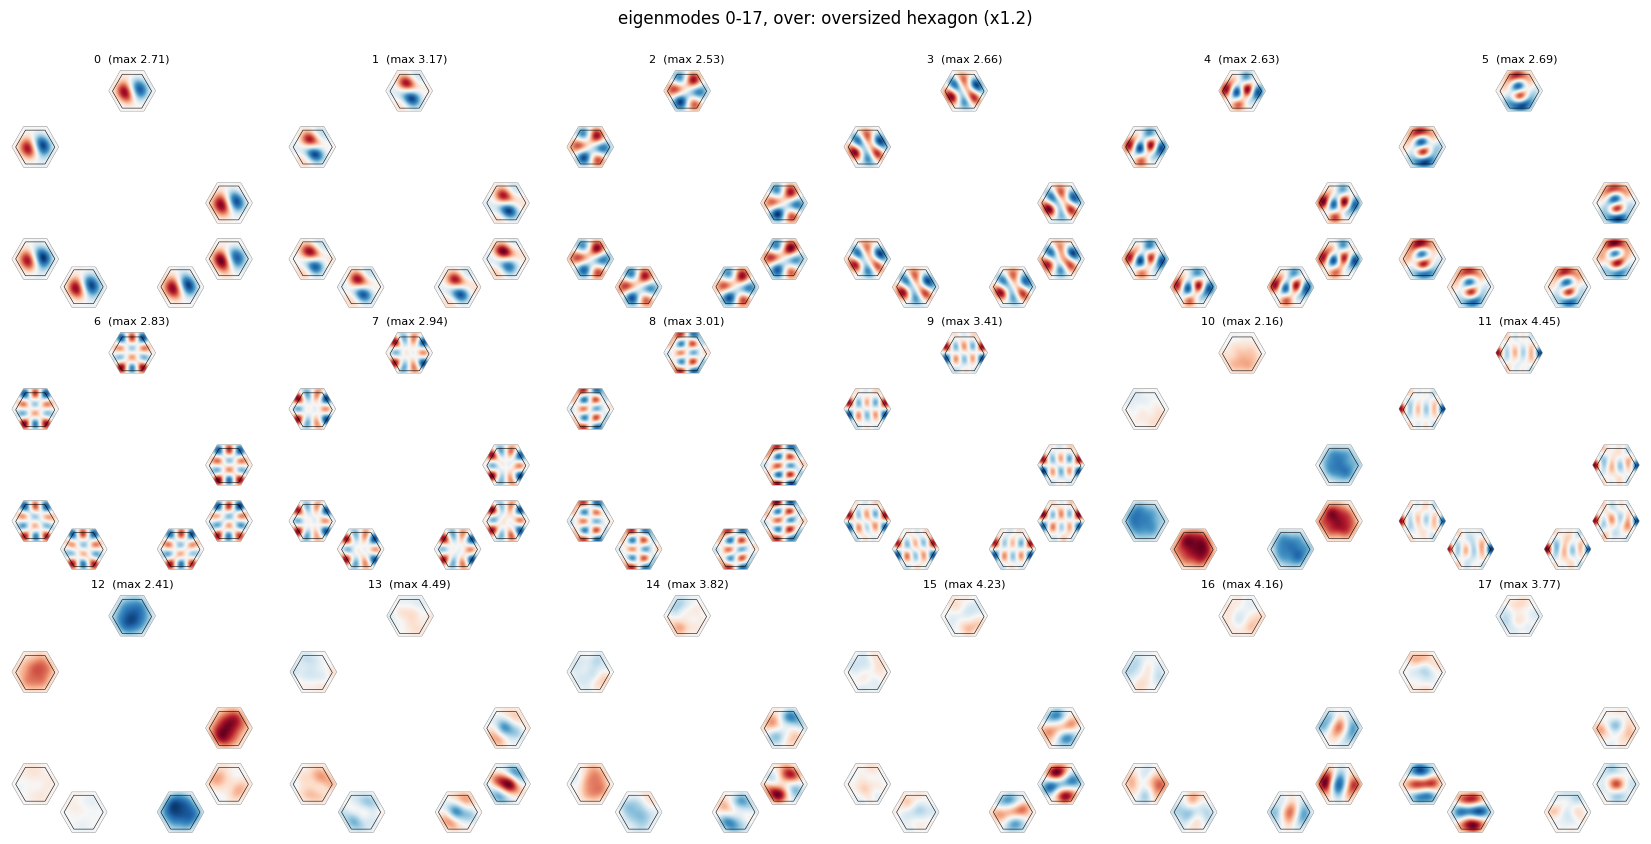

In [19]:
def show_eigen(start=0, n=12, mask_name=f"oversized hexagon (x{OVERSIZE})", ncols=6):
    m = MASKS[mask_name] > 0.5
    shown = onp.asarray(om.fill(np.asarray(m, float), corners, NPIX)) > 0
    true_full = onp.asarray(transmission)
    ys, xs = onp.where(supp_full)
    sl = (slice(ys.min() - 5, ys.max() + 5), slice(xs.min() - 5, xs.max() + 5))
    ks = list(range(start, min(start + n, n_eig)))
    nrows = math.ceil(len(ks) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.8 * ncols, 2.8 * nrows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, k in zip(axes.ravel(), ks):
        im = onp.asarray(om.fill(np.asarray(eigen[k] * m), corners, NPIX))[sl]
        v = onp.abs(im).max() or 1
        a.imshow(onp.where(shown[sl], im, onp.nan), cmap="RdBu_r", vmin=-v, vmax=v)
        a.contour(true_full[sl], [0.5], colors="k", linewidths=0.4)
        a.set_title(f"{k}  (max {v:.2f})", fontsize=8)
    fig.suptitle(f"eigenmodes {ks[0]}-{ks[-1]}, over: {mask_name}", y=1.0)
    plt.tight_layout()
    plt.show()


show_eigen(0, 18)

In [ ]:
import ipywidgets as w

w.interact(
    lambda start, mask_name: show_eigen(start, 12, mask_name),
    start=w.IntSlider(0, 0, n_eig - 1, step=6, description="first mode"),
    mask_name=w.Dropdown(options=list(MASKS), value=f"oversized hexagon (x{OVERSIZE})", description="mask"),
)

interactive(children=(IntSlider(value=0, description='first mode', max=99, step=6), Dropdown(description='mask…

<function __main__.<lambda>(start, mask_name)>